In [1]:
#Apply Raw
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np

# Load dataset
df= pd.read_csv("data/AmesHousing_engineered.csv")

# Drop target and ID columns
X = df.drop(columns=["SalePrice", "PID", "Order"], errors="ignore")
print("Features shape (raw version):", X.shape)

#Define Cluster Parameters
k_values = range(2, 9)  # clusters 2–8 for KMeans, GMM, Agglomerative, Spectral
n_init = 10  # random initialization for KMeans, GMM, Spectral
dbscan_eps = [0.5, 1.0, 1.5]  # DBSCAN eps values
min_samples = 5

#Function to Compute Metrics
def compute_metrics(X_data, labels):
    sil = silhouette_score(X_data, labels)
    db = davies_bouldin_score(X_data, labels)
    ch = calinski_harabasz_score(X_data, labels)
    return sil, db, ch



Features shape (raw version): (2930, 172)


In [2]:
#Apply Algorithms on Raw
#K-Means on Raw Features

kmeans_scores = []
for k in k_values:
    kmeans = KMeans(n_clusters=k, n_init=n_init, random_state=42)
    kmeans.fit(X)
    labels = kmeans.labels_
    sil, db, ch = compute_metrics(X, labels)
    kmeans_scores.append({"algorithm":"K-Means","preprocessing":"raw","k":k,"silhouette":sil,"davies_bouldin":db,"calinski_harabasz":ch})

#GMM on Raw Features
gmm_scores = []
for k in k_values:
    gmm = GaussianMixture(n_components=k, n_init=n_init, random_state=42)
    gmm.fit(X)
    labels = gmm.predict(X)
    sil, db, ch = compute_metrics(X, labels)
    gmm_scores.append({"algorithm":"GMM","preprocessing":"raw","k":k,"silhouette":sil,"davies_bouldin":db,"calinski_harabasz":ch})

#Agglomerative Clustering
agg_scores = []
for k in k_values:
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    agg.fit(X)
    labels = agg.labels_
    sil, db, ch = compute_metrics(X, labels)
    agg_scores.append({"algorithm":"Agglomerative","preprocessing":"raw","k":k,"silhouette":sil,"davies_bouldin":db,"calinski_harabasz":ch})

#Spectral Clustering
spectral_scores = []
for k in k_values:
    spectral = SpectralClustering(n_clusters=k, affinity='nearest_neighbors', n_init=n_init, random_state=42)
    spectral.fit(X)
    labels = spectral.labels_
    sil, db, ch = compute_metrics(X, labels)
    spectral_scores.append({"algorithm":"Spectral","preprocessing":"raw","k":k,"silhouette":sil,"davies_bouldin":db,"calinski_harabasz":ch})


#DBSCAN
dbscan_scores = []
for eps in dbscan_eps:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    dbscan.fit(X)
    labels = dbscan.labels_
    sil, db, ch = compute_metrics(X, labels)
    dbscan_scores.append({"algorithm":"DBSCAN","preprocessing":"raw","eps":eps,"silhouette":sil,"davies_bouldin":db,"calinski_harabasz":ch})



In [3]:
#Apply StandardScaler
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np

# Load dataset
df= pd.read_csv("data/AmesHousing_engineered.csv")

# Drop target and ID columns
X = df.drop(columns=["SalePrice", "PID", "Order"], errors="ignore")
print("Features shape (scaled version):", X.shape)

#Apply StandardScaler
#Now X_scaled contains all features standardized (mean = 0, std = 1)
scaler = StandardScaler()
X_s = scaler.fit_transform(X)

#Define Clustering Parameters
k_values = range(2, 9)  
n_init = 10              
dbscan_eps = [0.5, 1.0, 1.5]  
min_samples = 5

#Function to Compute Metrics
def compute_metrics(X_data, labels):
    sil = silhouette_score(X_data, labels)
    db = davies_bouldin_score(X_data, labels)
    ch = calinski_harabasz_score(X_data, labels)
    return sil, db, ch

Features shape (scaled version): (2930, 172)


In [4]:
#Apply Algorithms on Scaled
#K-Means on Scaled Data
results_scaled = []
for k in k_values:
    km = KMeans(n_clusters=k, n_init=n_init, random_state=42)
    labels = km.fit_predict(X_s)
    sil, db, ch = compute_metrics(X_s, labels)
    results_scaled.append({"algorithm": "KMeans", "preprocessing": "StandardScaler", "k": k, "silhouette": sil, "davies_bouldin": db, "calinski_harabasz": ch})

#Gaussian Mixture (GMM)on Scaled Data
results_scaled_gmm = []
for k in k_values:
    gmm = GaussianMixture(n_components=k, n_init=n_init, random_state=42)
    labels = gmm.fit_predict(X_s)
    sil, db, ch = compute_metrics(X_s, labels)
    results_scaled_gmm.append({"algorithm": "GMM", "preprocessing": "StandardScaler", "k": k, "silhouette": sil, "davies_bouldin": db, "calinski_harabasz": ch})

#Agglomerative Clustering on Scaled Data
results_scaled_agg = []
for k in k_values:
    agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = agg.fit_predict(X_s)
    sil, db, ch = compute_metrics(X_s, labels)
    results_scaled_agg.append({"algorithm": "Agglomerative", "preprocessing": "StandardScaler", "k": k, "silhouette": sil, "davies_bouldin": db, "calinski_harabasz": ch})


#Spectral Clustering on Scaled Data
results_scaled_spec = []
for k in k_values:
    spec = SpectralClustering(n_clusters=k, affinity="nearest_neighbors")
    labels = spec.fit_predict(X_s)
    sil, db, ch = compute_metrics(X_s, labels)
    results_scaled_spec.append({"algorithm": "Spectral", "preprocessing": "StandardScaler", "k": k, "silhouette": sil, "davies_bouldin": db, "calinski_harabasz": ch})

#DBSCAN on Scaled Data
results_scaled_dbscan = []
for eps in dbscan_eps:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X_s)
    
    # Remove noise points (-1)
    mask = labels != -1
    if np.sum(mask) > 1:  # silhouette requires >= 2 points
        sil, db, ch = compute_metrics(X_s[mask], labels[mask])
        results_scaled_dbscan.append({"algorithm": "DBSCAN", "preprocessing": "StandardScaler", "eps": eps, "silhouette": sil, "davies_bouldin": db, "calinski_harabasz": ch})


In [5]:
#Apply StandardScaler + PCA
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np

# Load dataset
df= pd.read_csv("data/AmesHousing_engineered.csv")

# Drop target and ID columns
X = df.drop(columns=["SalePrice", "PID", "Order"], errors="ignore")
# Apply StandardScaler
scaler = StandardScaler()
X_sp = scaler.fit_transform(X)

print("Scaled features shape:", X_sp.shape)

#Apply PCA

pca = PCA(n_components=30, random_state=42)
X_pca = pca.fit_transform(X_sp)
#print("PCA features shape:", X_pca.shape)
print("PCA-reduced features shape:", X_pca.shape)
print("Explained variance ratio sum:", sum(pca.explained_variance_ratio_))

#Define Clustering Parameters
k_values = range(2, 9)  # clusters for KMeans, GMM, Agglomerative, Spectral
n_init = 10              # random initialization
dbscan_eps = [0.5, 1.0, 1.5]  # DBSCAN eps values
min_samples = 5

#Function to Compute Metrics
def compute_metrics(X_data, labels):
    sil = silhouette_score(X_data, labels)
    db = davies_bouldin_score(X_data, labels)
    ch = calinski_harabasz_score(X_data, labels)
    return sil, db, ch



Scaled features shape: (2930, 172)
PCA-reduced features shape: (2930, 30)
Explained variance ratio sum: 0.9933085699298378


In [6]:
##Apply StandardScaler + PCA
#K-Means on Scaled + PCA Data
results_scaled_pca = []
for k in k_values:
    km = KMeans(n_clusters=k, n_init=n_init, random_state=42)
    labels = km.fit_predict(X_pca)
    sil, db, ch = compute_metrics(X_pca, labels)
    results_scaled_pca.append({"algorithm": "KMeans", "preprocessing": "StandardScaler+PCA", "k": k, "silhouette": sil, "davies_bouldin": db, "calinski_harabasz": ch})

#Gaussian Mixture (GMM)on Scaled + PCA Data
results_scaled_pca_gmm = []
for k in k_values:
    gmm = GaussianMixture(n_components=k, n_init=n_init, random_state=42)
    labels = gmm.fit_predict(X_pca)
    sil, db, ch = compute_metrics(X_pca, labels)
    results_scaled_pca_gmm.append({"algorithm": "GMM", "preprocessing": "StandardScaler+PCA", "k": k, "silhouette": sil, "davies_bouldin": db, "calinski_harabasz": ch})


#Agglomerative Clustering on Scaled + PCA Data
results_scaled_pca_agg = []
for k in k_values:
    agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = agg.fit_predict(X_pca)
    sil, db, ch = compute_metrics(X_pca, labels)
    results_scaled_pca_agg.append({"algorithm": "Agglomerative", "preprocessing": "StandardScaler+PCA", "k": k, "silhouette": sil, "davies_bouldin": db, "calinski_harabasz": ch})


#Spectral Clustering on Scaled + PCA Data
results_scaled_pca_spec = []
for k in k_values:
    spec = SpectralClustering(n_clusters=k, affinity="nearest_neighbors")
    labels = spec.fit_predict(X_pca)
    sil, db, ch = compute_metrics(X_pca, labels)
    results_scaled_pca_spec.append({"algorithm": "Spectral", "preprocessing": "StandardScaler+PCA", "k": k, "silhouette": sil, "davies_bouldin": db, "calinski_harabasz": ch})

#DBSCAN on Scaled + PCA Data
results_scaled_pca_dbscan = []
for eps in dbscan_eps:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X_pca)
    
    # Remove noise points (-1)
    mask = labels != -1
    if np.sum(mask) > 1:  # silhouette requires >= 2 points
        sil, db, ch = compute_metrics(X_pca[mask], labels[mask])
        results_scaled_pca_dbscan.append({"algorithm": "DBSCAN", "preprocessing": "StandardScaler+PCA", "eps": eps, "silhouette": sil, "davies_bouldin": db, "calinski_harabasz": ch})


In [7]:
#Apply StandardScaler + Outliers Removal 
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np
#from sklearn.ensemble import IsolationForest
# Load dataset
df= pd.read_csv("data/AmesHousing_engineered.csv")

# Drop target and ID columns
X = df.drop(columns=["SalePrice", "PID", "Order"], errors="ignore")
# Apply StandardScaler
scaler = StandardScaler()
X_so = scaler.fit_transform(X)

print("Scaled features shape:", X_so.shape)

# iso = IsolationForest(contamination=0.02, random_state=42)
# labels = iso.fit_predict(X_so)
# X_scaled_out = X_so[labels == 1]
#Define Clustering Parameters
k_values = range(2, 9)  # clusters for KMeans, GMM, Agglomerative, Spectral
n_init = 10              # random initialization
dbscan_eps = [0.5, 1.0, 1.5]  # DBSCAN eps values
min_samples = 5

#Function to Compute Metrics
def compute_metrics(X_data, labels):
    sil = silhouette_score(X_data, labels)
    db = davies_bouldin_score(X_data, labels)
    ch = calinski_harabasz_score(X_data, labels)
    return sil, db, ch

#Outlier Detection & Removal
from scipy.stats import zscore

# Compute z-scores
z_scores = np.abs(zscore(X_so))

# Remove rows where any feature has z > threshold (e.g., 3)
threshold = 3
# mask = (z_scores < threshold).all(axis=1)
mask = (z_scores < threshold).mean(axis=1) > 0.95
X_scaled_out = X_so[mask]

print("Shape after outlier removal:", X_scaled_out.shape)



Scaled features shape: (2930, 172)
Shape after outlier removal: (0, 172)


C:\Users\shetu\AppData\Local\Temp\ipykernel_28052\1497100573.py:40: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  z_scores = np.abs(zscore(X_so))


In [ ]:
#K-Means on Scaled + OutlierRemoval Data
results_scaled_out = []
for k in k_values:
    km = KMeans(n_clusters=k, n_init=n_init, random_state=42)
    labels = km.fit_predict(X_scaled_out)
    sil, db, ch = compute_metrics(X_scaled_out, labels)
    results_scaled_out.append({"algorithm": "KMeans", "preprocessing": "StandardScaler+OutlierRemoval", "k": k, "silhouette": sil, "davies_bouldin": db, "calinski_harabasz": ch})



#Gaussian Mixture (GMM)on Scaled + OutlierRemoval Data
results_scaled_out_gmm = []
for k in k_values:
    gmm = GaussianMixture(n_components=k, n_init=n_init, random_state=42)
    labels = gmm.fit_predict(X_scaled_out)
    sil, db, ch = compute_metrics(X_scaled_out, labels)
    results_scaled_out_gmm.append({"algorithm": "GMM", "preprocessing": "StandardScaler+OutlierRemoval", "k": k, "silhouette": sil, "davies_bouldin": db, "calinski_harabasz": ch})



#Agglomerative Clustering on Scaled + OutlierRemoval Data
results_scaled_out_agg = []
for k in k_values:
    agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = agg.fit_predict(X_scaled_out)
    sil, db, ch = compute_metrics(X_scaled_out, labels)
    results_scaled_out_agg.append({"algorithm": "Agglomerative", "preprocessing": "StandardScaler+OutlierRemoval", "k": k, "silhouette": sil, "davies_bouldin": db, "calinski_harabasz": ch})


#Spectral Clustering on Scaled + OutlierRemoval Data
results_scaled_out_spec = []
for k in k_values:
    spec = SpectralClustering(n_clusters=k, affinity="nearest_neighbors")
    labels = spec.fit_predict(X_scaled_out)
    sil, db, ch = compute_metrics(X_scaled_out, labels)
    results_scaled_out_spec.append({"algorithm": "Spectral", "preprocessing": "StandardScaler+OutlierRemoval", "k": k, "silhouette": sil, "davies_bouldin": db, "calinski_harabasz": ch})


#DBSCAN on Scaled + OutlierRemoval Data
results_scaled_out_dbscan = []
for eps in dbscan_eps:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X_scaled_out)
    
    # Remove noise points (-1)
    mask = labels != -1
    if np.sum(mask) > 1:  # silhouette requires >= 2 points
        sil, db, ch = compute_metrics(X_scaled_out[mask], labels[mask])
        results_scaled_out_dbscan.append({"algorithm": "DBSCAN", "preprocessing": "StandardScaler+OutlierRemoval", "eps": eps, "silhouette": sil, "davies_bouldin": db, "calinski_harabasz": ch})


In [ ]:
# Apply StandardScaler + Outliers Removal + PCA
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np
from scipy.stats import zscore
#from sklearn.ensemble import IsolationForest
# Load dataset
df= pd.read_csv("data/AmesHousing_engineered.csv")

# Drop target and ID columns
X = df.drop(columns=["SalePrice", "PID", "Order"], errors="ignore")
# Apply StandardScaler
scaler = StandardScaler()
X_spo = scaler.fit_transform(X)

print("Scaled features shape:", X_spo.shape)

#Define Clustering Parameters
k_values = range(2, 9)  # clusters for KMeans, GMM, Agglomerative, Spectral
n_init = 10              # random initialization
dbscan_eps = [0.5, 1.0, 1.5]  # DBSCAN eps values
min_samples = 5

#Function to Compute Metrics
def compute_metrics(X_data, labels):
    sil = silhouette_score(X_data, labels)
    db = davies_bouldin_score(X_data, labels)
    ch = calinski_harabasz_score(X_data, labels)
    return sil, db, ch

#Apply PCA

pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_spo)
#print("PCA features shape:", X_pca.shape)
print("PCA-reduced features shape:", X_pca.shape)
print("Explained variance ratio sum:", sum(pca.explained_variance_ratio_))

#Outlier Detection & Removal (Z-score)
# Compute z-scores on PCA components
z_scores = np.abs(zscore(X_pca))

# Threshold (e.g., z > 3)
threshold = 3
mask = (z_scores < threshold).all(axis=1)

X_final = X_pca[mask]

print("Shape after PCA + Outlier Removal:", X_final.shape)



Scaled features shape: (2930, 172)
PCA-reduced features shape: (2930, 25)
Explained variance ratio sum: 0.9587142612380308
Shape after PCA + Outlier Removal: (2650, 25)


In [16]:
#K-Means on Scaled + PCA + outliersremoval Data
results_scal_pca_out = []
for k in k_values:
    km = KMeans(n_clusters=k, n_init=n_init, random_state=42)
    labels = km.fit_predict(X_final)
    sil, db, ch = compute_metrics(X_final, labels)
    results_scal_pca_out.append({"algorithm": "KMeans", "preprocessing": "StandardScaler+PCA+OutlierRemoval", "k": k, "silhouette": sil, "davies_bouldin": db, "calinski_harabasz": ch})

#Gaussian Mixture (GMM)on Scaled + PCA + outliersremoval Data
results_scal_pca_out_gmm = []
for k in k_values:
    gmm = GaussianMixture(n_components=k, n_init=n_init, random_state=42)
    labels = gmm.fit_predict(X_final)
    sil, db, ch = compute_metrics(X_final, labels)
    results_scal_pca_out_gmm.append({"algorithm": "GMM", "preprocessing": "StandardScaler+PCA+OutlierRemoval", "k": k, "silhouette": sil, "davies_bouldin": db, "calinski_harabasz": ch})


#Agglomerative Clustering on Scaled + PCA + outliersremoval Data
results_scal_pca_out_agg = []
for k in k_values:
    agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = agg.fit_predict(X_final)
    sil, db, ch = compute_metrics(X_final, labels)
    results_scal_pca_out_agg.append({"algorithm": "Agglomerative", "preprocessing": "StandardScaler+PCA+OutlierRemoval", "k": k, "silhouette": sil, "davies_bouldin": db, "calinski_harabasz": ch})


#Spectral Clustering on Scaled + PCA + outliersremoval Data
results_scal_pca_out_spec = []
for k in k_values:
    spec = SpectralClustering(n_clusters=k, affinity="nearest_neighbors")
    labels = spec.fit_predict(X_final)
    sil, db, ch = compute_metrics(X_final, labels)
    results_scal_pca_out_spec.append({"algorithm": "Spectral", "preprocessing": "StandardScaler+PCA+OutlierRemoval", "k": k, "silhouette": sil, "davies_bouldin": db, "calinski_harabasz": ch})


#DBSCAN on Scaled + PCA + outliersremoval Data
results_scal_pca_out_dbscan = []
for eps in dbscan_eps:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X_final)
    
    # Remove noise points (-1)
    mask = labels != -1
    if np.sum(mask) > 1:  # silhouette requires >= 2 points
        sil, db, ch = compute_metrics(X_final[mask], labels[mask])
        results_scal_pca_out_dbscan.append({"algorithm": "DBSCAN", "preprocessing": "StandardScaler+PCA+OutlierRemoval", "eps": eps, "silhouette": sil, "davies_bouldin": db, "calinski_harabasz": ch})



In [ ]:
# import csv

# results = (kmeans_scores + gmm_scores + agg_scores + spectral_scores + dbscan_scores+
#            results_scaled + results_scaled_gmm + results_scaled_agg + results_scaled_spec + results_scaled_dbscan+
#            results_scaled_pca + results_scaled_pca_gmm + results_scaled_pca_agg + results_scaled_pca_spec + results_scaled_pca_dbscan+
#            results_scaled_out + results_scaled_out_gmm + results_scaled_out_agg + results_scaled_out_spec + results_scaled_out_dbscan+
#            results_scal_pca_out + results_scal_pca_out_gmm + results_scal_pca_out_agg + results_scal_pca_out_spec + results_scal_pca_out_dbscan)

# # # Desired column order
# keys = ["algorithm", "preprocessing", "k", "silhouette", "davies_bouldin", "calinski_harabasz", "eps"]
# with open('updated_data/ames_scores.csv', 'w', newline='') as file:
#     writer = csv.DictWriter(file, fieldnames=keys, extrasaction="ignore")
#     writer.writeheader()
#     writer.writerows(results)


# import csv
# results_raw = (kmeans_scores + gmm_scores + agg_scores + spectral_scores + dbscan_scores)
# keys = ["algorithm", "preprocessing", "k", "silhouette", "davies_bouldin", "calinski_harabasz", "eps"]
# with open('ames_data/ames_raw_scores.csv', 'w', newline='') as file:
#     writer = csv.DictWriter(file, fieldnames=keys, extrasaction="ignore")
#     writer.writeheader()
#     writer.writerows(results_raw)

# import csv
# results_scaled = (results_scaled + results_scaled_gmm + results_scaled_agg + results_scaled_spec + results_scaled_dbscan)
# keys = ["algorithm", "preprocessing", "k", "silhouette", "davies_bouldin", "calinski_harabasz", "eps"]
# with open('ames_data/ames_scaled_scores.csv', 'w', newline='') as file:
#     writer = csv.DictWriter(file, fieldnames=keys, extrasaction="ignore")
#     writer.writeheader()
#     writer.writerows(results_scaled)

# import csv
# results_scaled_pca = (results_scaled_pca + results_scaled_pca_gmm + results_scaled_pca_agg + results_scaled_pca_spec + results_scaled_pca_dbscan)
# keys = ["algorithm", "preprocessing", "k", "silhouette", "davies_bouldin", "calinski_harabasz", "eps"]
# with open('ames_data/ames_scaled_pca_scores.csv', 'w', newline='') as file:
#     writer = csv.DictWriter(file, fieldnames=keys, extrasaction="ignore")
#     writer.writeheader()
#     writer.writerows(results_scaled_pca)

#import csv
# results_scaled_out = (results_scaled_out + results_scaled_out_gmm + results_scaled_out_agg + results_scaled_out_spec + results_scaled_out_dbscan)
# keys = ["algorithm", "preprocessing", "k", "silhouette", "davies_bouldin", "calinski_harabasz", "eps"]
# with open('ames_data/ames_scaled_outliers_scores.csv', 'w', newline='') as file:
#     writer = csv.DictWriter(file, fieldnames=keys, extrasaction="ignore")
#     writer.writeheader()
#     writer.writerows(results_scaled_out)

import csv
results_scal_pca_out = (results_scal_pca_out + results_scal_pca_out_gmm + results_scal_pca_out_agg + results_scal_pca_out_spec + results_scal_pca_out_dbscan)
keys = ["algorithm", "preprocessing", "k", "silhouette", "davies_bouldin", "calinski_harabasz", "eps"]
with open('ames_data/ames_scaled_pca_out_scores.csv', 'w', newline='') as file:
    writer = csv.DictWriter(file, fieldnames=keys, extrasaction="ignore")
    writer.writeheader()
    writer.writerows(results_scal_pca_out)
   
    
    
    

In [9]:
import pandas as pd
import numpy as np
print("RAW:", X.shape)
print("SCALED:", X_s.shape)
print("SCALED PCA:", X_pca.shape)
print("SCALED OUTLIER:", X_scaled_out.shape)
print("SCALED PCA OUTLIER:", X_final.shape)

RAW: (2930, 172)
SCALED: (2930, 172)
SCALED PCA: (2930, 30)
SCALED OUTLIER: (0, 172)
SCALED PCA OUTLIER: (2570, 30)


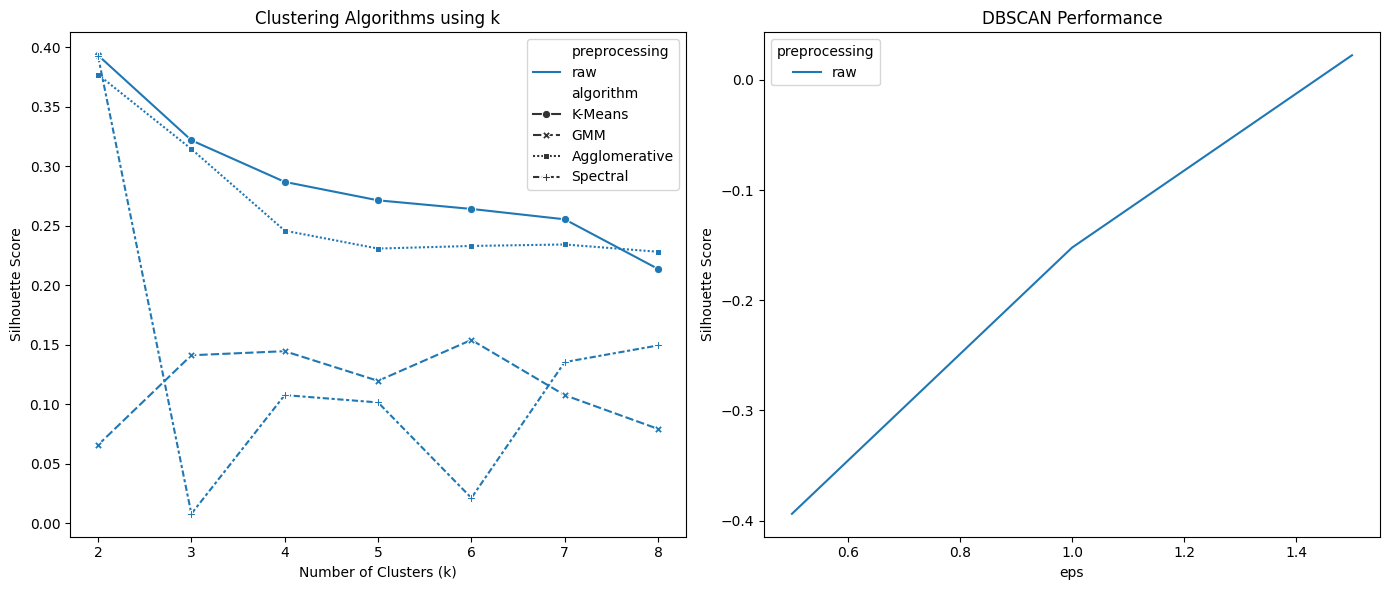

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns


df_raw = pd.read_csv("updated_data/ames_raw_scores.csv")
df_raw.columns = df_raw.columns.str.strip().str.lower()
# df_raw.columns = df_raw.columns.str.strip()
#df_raw
df_raw_k = df_raw[df_raw["algorithm"] != "DBSCAN"]
df_raw_dbscan = df_raw[df_raw["algorithm"] == "DBSCAN"]

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Plot algorithms using k
sns.lineplot(
    data=df_raw_k,
    x="k",
    y="silhouette",
    hue="preprocessing",
    style="algorithm",
    markers=True,
    ax=axes[0]
)

axes[0].set_title("Clustering Algorithms using k")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Silhouette Score")

# Plot DBSCAN
sns.lineplot(
    data=df_raw_dbscan,
    x="eps",
    y="silhouette",
    hue="preprocessing",
    markers=True,
    #ax=axes[1]
)

axes[1].set_title("DBSCAN Performance")
axes[1].set_xlabel("eps")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

In [ ]:
#compares algorithms across preprocessing methods
df_raw = pd.read_csv("updated_data/ames_raw_scores.csv")
df_raw.columns = df_raw.columns.str.strip().str.lower()

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_raw,
    x="algorithm",
    y="silhouette",
    hue="preprocessing"
)

plt.title("Algorithm Performance Across Preprocessing Strategies")
plt.xlabel("Clustering Algorithm")
plt.ylabel("Silhouette Score")

plt.legend(bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

In [ ]:
#Preprocessing Impact Heatmap
df_raw = pd.read_csv("updated_data/ames_raw_scores.csv")
df_raw.columns = df_raw.columns.str.strip().str.lower()

pivot = df_raw.pivot_table(
    values="silhouette",
    index="algorithm",
    columns="preprocessing"
)

plt.figure(figsize=(8,6))

sns.heatmap(
    pivot,
    annot=True,
    cmap="viridis"
)

plt.title("Clustering Performance Heatmap")
plt.show()

In [ ]:
#Stability Plot 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


stability = df_raw.groupby(["algorithm", "preprocessing"])["silhouette"].std().reset_index()

plt.figure(figsize=(10,6))

sns.barplot(
    data=stability,
    x="algorithm",
    y="silhouette",
    hue="preprocessing"
)

plt.title("Clustering Stability (Std of Silhouette Score)")
plt.ylabel("Standard Deviation")
plt.tight_layout()
plt.show()

In [3]:
# Apply StandardScaler + Outliers Removal + PCA
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np
from scipy.stats import zscore
from sklearn.ensemble import IsolationForest
# Load dataset
df= pd.read_csv("data/AmesHousing_engineered.csv")

# Drop target and ID columns
X = df.drop(columns=["SalePrice", "PID", "Order"], errors="ignore")
# Apply StandardScaler
scaler = StandardScaler()
X_sop = scaler.fit_transform(X)

print("Scaled features shape:", X_sop.shape)

#Define Clustering Parameters
k_values = range(2, 15)  # clusters for KMeans, GMM, Agglomerative, Spectral
n_init = 10              # random initialization
dbscan_eps = [0.5, 1.0, 1.5]  # DBSCAN eps values
min_samples = 30

#Function to Compute Metrics
def compute_metrics(X_data, labels):
    sil = silhouette_score(X_data, labels)
    db = davies_bouldin_score(X_data, labels)
    ch = calinski_harabasz_score(X_data, labels)
    return sil, db, ch

#Apply PCA

pca = PCA(n_components=30, random_state=42)
X_pca = pca.fit_transform(X_sop)
#print("PCA features shape:", X_pca.shape)
print("PCA-reduced features shape:", X_pca.shape)
print("Explained variance ratio sum:", sum(pca.explained_variance_ratio_))

#Outlier Detection & Removal (Z-score)
# Compute z-scores on PCA components
z_scores = np.abs(zscore(X_pca))

# Threshold (e.g., z > 3)
threshold = 3
mask = (z_scores < threshold).all(axis=1)

X_final = X_pca[mask]

print("Shape after PCA + Outlier Removal:", X_final.shape)



Scaled features shape: (2930, 172)
PCA-reduced features shape: (2930, 30)
Explained variance ratio sum: 0.9933085699298378
Shape after PCA + Outlier Removal: (2570, 30)


In [4]:
#K-Means on Scaled + PCA + outliersremoval Data
results_scal_pca_out = []
for k in k_values:
    km = KMeans(n_clusters=k, n_init=n_init, random_state=42)
    labels = km.fit_predict(X_sop)
    sil, db, ch = compute_metrics(X_sop, labels)
    results_scal_pca_out.append({"algorithm": "KMeans", "preprocessing": "StandardScaler+PCA+OutlierRemoval", "k": k, "silhouette": sil, "davies_bouldin": db, "calinski_harabasz": ch})

#Gaussian Mixture (GMM)on Scaled + PCA + outliersremoval Data
results_scal_pca_out_gmm = []
for k in k_values:
    gmm = GaussianMixture(n_components=k, n_init=n_init, random_state=42)
    labels = gmm.fit_predict(X_sop)
    sil, db, ch = compute_metrics(X_sop, labels)
    results_scal_pca_out_gmm.append({"algorithm": "GMM", "preprocessing": "StandardScaler+PCA+OutlierRemoval", "k": k, "silhouette": sil, "davies_bouldin": db, "calinski_harabasz": ch})


#Agglomerative Clustering on Scaled + PCA + outliersremoval Data
results_scal_pca_out_agg = []
for k in k_values:
    agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = agg.fit_predict(X_sop)
    sil, db, ch = compute_metrics(X_sop, labels)
    results_scal_pca_out_agg.append({"algorithm": "Agglomerative", "preprocessing": "StandardScaler+PCA+OutlierRemoval", "k": k, "silhouette": sil, "davies_bouldin": db, "calinski_harabasz": ch})


#Spectral Clustering on Scaled + PCA + outliersremoval Data
results_scal_pca_out_spec = []
for k in k_values:
    spec = SpectralClustering(n_clusters=k, affinity="nearest_neighbors")
    labels = spec.fit_predict(X_sop)
    sil, db, ch = compute_metrics(X_sop, labels)
    results_scal_pca_out_spec.append({"algorithm": "Spectral", "preprocessing": "StandardScaler+PCA+OutlierRemoval", "k": k, "silhouette": sil, "davies_bouldin": db, "calinski_harabasz": ch})


#DBSCAN on Scaled + PCA + outliersremoval Data
results_scal_pca_out_dbscan = []
for eps in dbscan_eps:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X_sop)
    
    # Remove noise points (-1)
    mask = labels != -1
    if np.sum(mask) > 1:  # silhouette requires >= 2 points
        sil, db, ch = compute_metrics(X_sop[mask], labels[mask])
        results_scal_pca_out_dbscan.append({"algorithm": "DBSCAN", "preprocessing": "StandardScaler+PCA+OutlierRemoval", "eps": eps, "silhouette": sil, "davies_bouldin": db, "calinski_harabasz": ch})



In [6]:
import csv

results_scal_pca_out = (results_scal_pca_out + results_scal_pca_out_gmm + results_scal_pca_out_agg + results_scal_pca_out_spec + results_scal_pca_out_dbscan)
keys = ["algorithm", "preprocessing", "k", "silhouette", "davies_bouldin", "calinski_harabasz", "eps"]
with open('updated_data/ames_Scatter_test.csv', 'w', newline='') as file:
    writer = csv.DictWriter(file, fieldnames=keys, extrasaction="ignore")
    writer.writeheader()
    writer.writerows(results_scal_pca_out)